# Active-SLAM experiment visualisation

Compare saved eQMARL, qfCTDE, fCTDE, and sCTDE runs, then inspect a two-robot frontier-policy rollout. Run training first so `experiment_output/active_slam_maa2c_*/` contains metric files.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

from eqmarl.active_slam_visualization import (
    animate_rollout, discover_metric_files, load_metrics, plot_learning_curves,
    plot_slam_frame, rollout, summarize_final_metrics,
)
from eqmarl.environments.active_slam import MultiAgentSLAMEnv
from eqmarl.policies import FrontierJointPolicy

In [9]:
groups = discover_metric_files(Path.cwd().parent / 'experiment_output')
if not groups:
    groups = discover_metric_files('experiment_output')
groups

{'eqmarl_psi+': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_eqmarl_psi+/20260728T182007/metrics-0.json')],
 'fctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_fctde/20260728T182301/metrics-0.json')],
 'qfctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_qfctde/20260728T182004/metrics-0.json')],
 'sctde': [PosixPath('/home/youngei402tw/projects/eqmarl/experiment_output/active_slam_maa2c_sctde/20260728T230631/metrics-0.json')]}

In [10]:
data = load_metrics(groups)
data.head()

,framework,run,episode,team_reward,coverage,occupancy_iou,pose_rmse,collisions,path_length,redundant_coverage,pose_uncertainty,success
0,eqmarl_psi+,0,0,-1.301215,0.605081,0.306818,4.487686,29.0,79.0,0.018018,0.559821,0.0
1,eqmarl_psi+,0,1,3.342947,0.866817,0.504065,0.651632,6.0,103.0,0.158898,0.257733,0.0
2,eqmarl_psi+,0,2,1.621496,0.883562,0.548611,1.152407,19.0,107.0,0.237805,0.231653,0.0
3,eqmarl_psi+,0,3,2.779859,0.883929,0.302521,2.902584,9.0,125.0,0.542735,0.258191,0.0
4,eqmarl_psi+,0,4,0.848917,0.731830,0.423358,1.985138,17.0,104.0,0.139896,0.245461,0.0


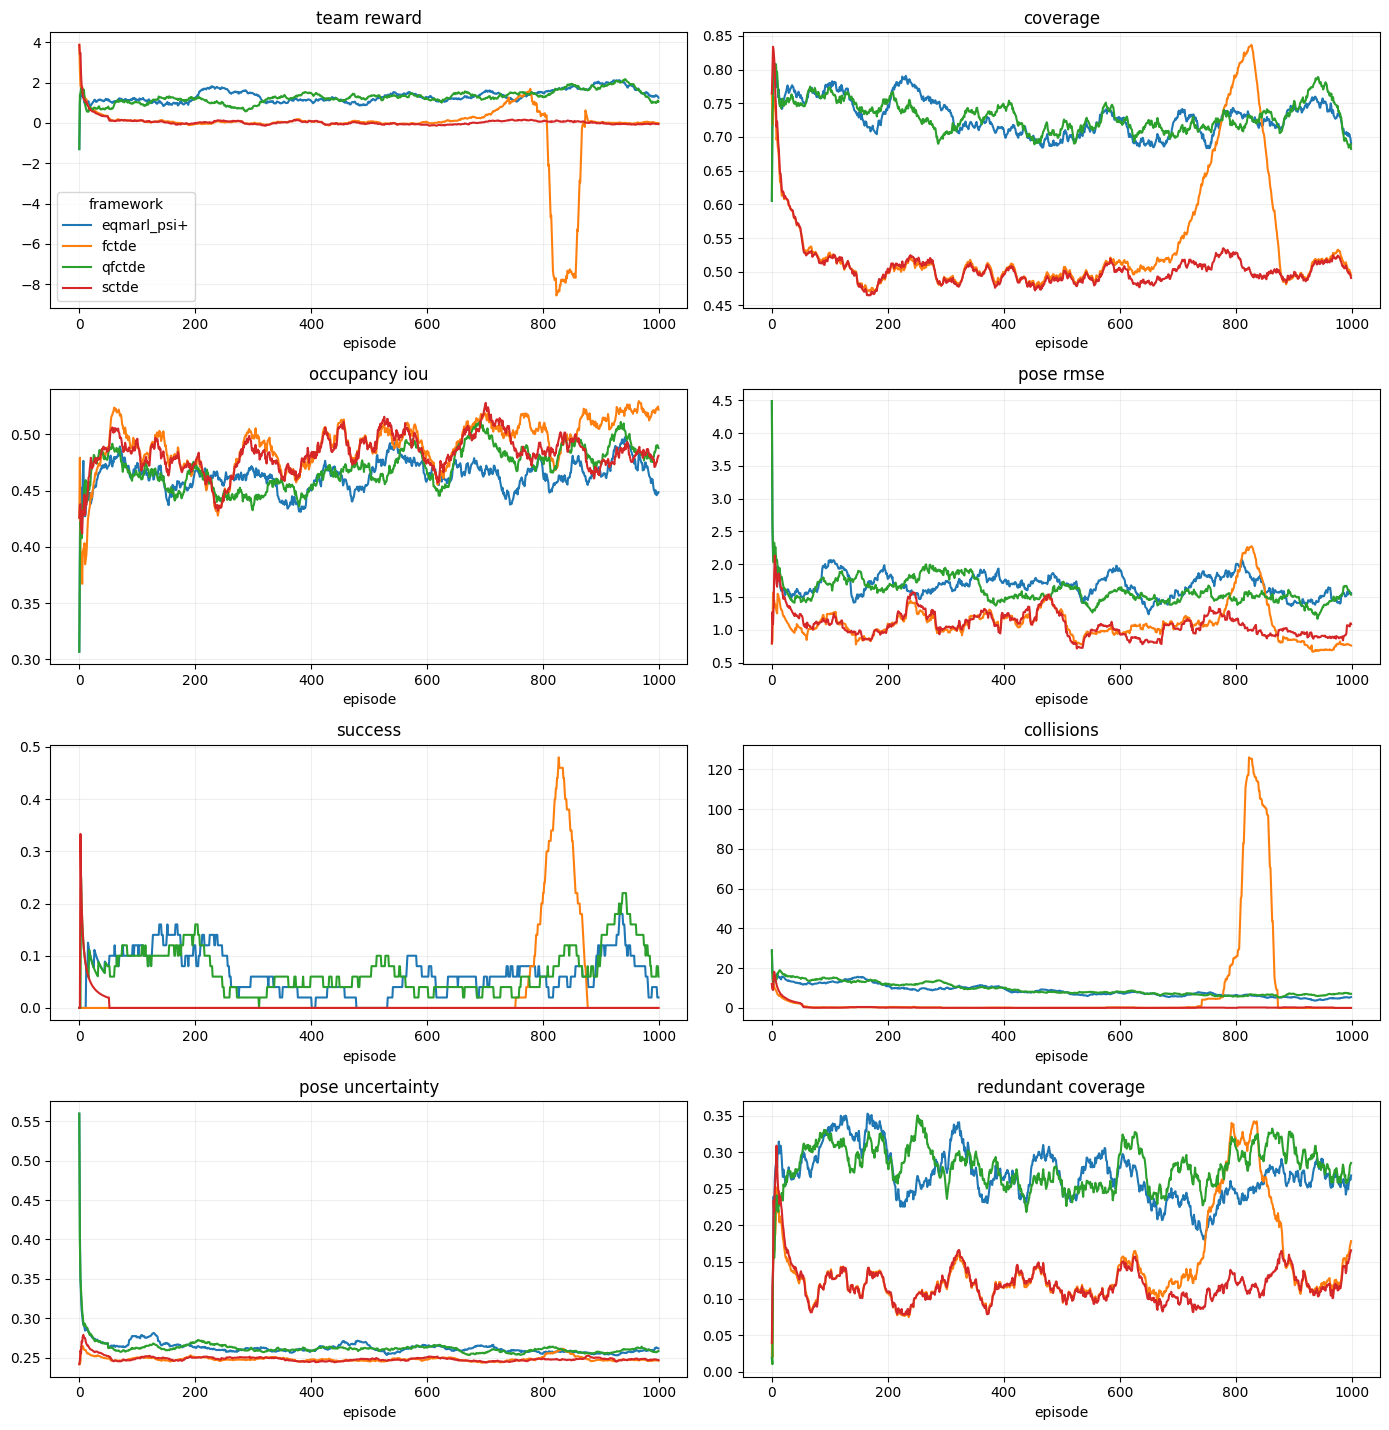

In [11]:
figure = plot_learning_curves(data, smoothing=50)
plt.show()

The table reports the mean final-window score per seed and its 95% confidence interval. `team_reward` is the learning objective; coverage, occupancy IoU, and pose RMSE measure the SLAM result directly.

In [12]:
summary = summarize_final_metrics(data, window=100)
summary.pivot(index='framework', columns='metric', values=['mean', 'ci95']).round(3)

mean                                                    \
metric      collisions coverage occupancy_iou pose_rmse pose_uncertainty   
framework                                                                  
eqmarl_psi+       4.72    0.722         0.469     1.540            0.260   
fctde             0.00    0.507         0.524     0.727            0.247   
qfctde            6.64    0.729         0.494     1.427            0.259   
sctde             0.10    0.504         0.481     0.999            0.247   

                                                         ci95           \
metric      redundant_coverage success team_reward collisions coverage   
framework                                                                
eqmarl_psi+              0.278    0.07       1.557        0.0      0.0   
fctde                    0.148    0.00      -0.013        0.0      0.0   
qfctde                   0.283    0.12       1.505        0.0      0.0   
sctde                    0.140    0.00      -0.065        0.0      0.0   

                                                                         \
metric      occupancy_iou pose_rmse pose_uncertainty redundant_coverage   
framework                                                                 
eqmarl_psi+           0.0       0.0              0.0                0.0   
fctde                 0.0       0.0              0.0                0.0   
qfctde                0.0       0.0              0.0                0.0   
sctde                 0.0       0.0              0.0                0.0   

                                 
metric      success team_reward  
framework                        
eqmarl_psi+     0.0         0.0  
fctde           0.0         0.0  
qfctde          0.0         0.0  
sctde           0.0         0.0

## Rollout inspection

This uses the deterministic frontier baseline, so the notebook remains usable before learned checkpoints are available. The left panel is the ground truth; the right panel is the conventional SLAM backend's fused occupancy belief.

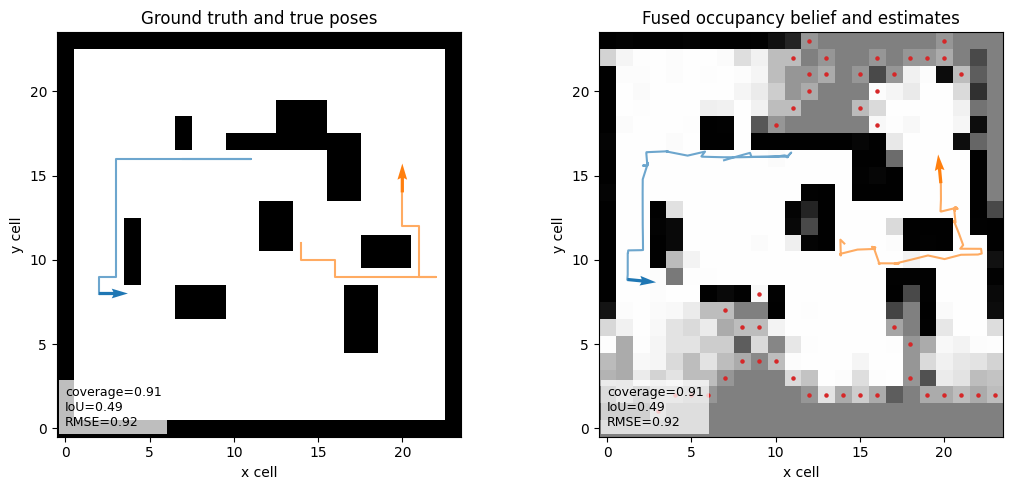

In [13]:
env = MultiAgentSLAMEnv(map_size=24, time_limit=80)
frames = rollout(env, FrontierJointPolicy(), seed=7)
figure = plot_slam_frame(frames[-1], history=frames)
plt.show()

In [ ]:
display(HTML(animate_rollout(frames, interval=220).to_jshtml()))